In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

In [3]:
# Read in the processed dataset
file_path = '../data/processed/processed_data_pre_model.csv'
df = pd.read_csv(file_path, parse_dates=['date'], date_format={'date': '%Y-%m-%d'})

C:\Users\sbout\AppData\Local\Temp\ipykernel_23856\1942631773.py:3: DtypeWarning: Columns (46,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, parse_dates=['date'], date_format={'date': '%Y-%m-%d'})


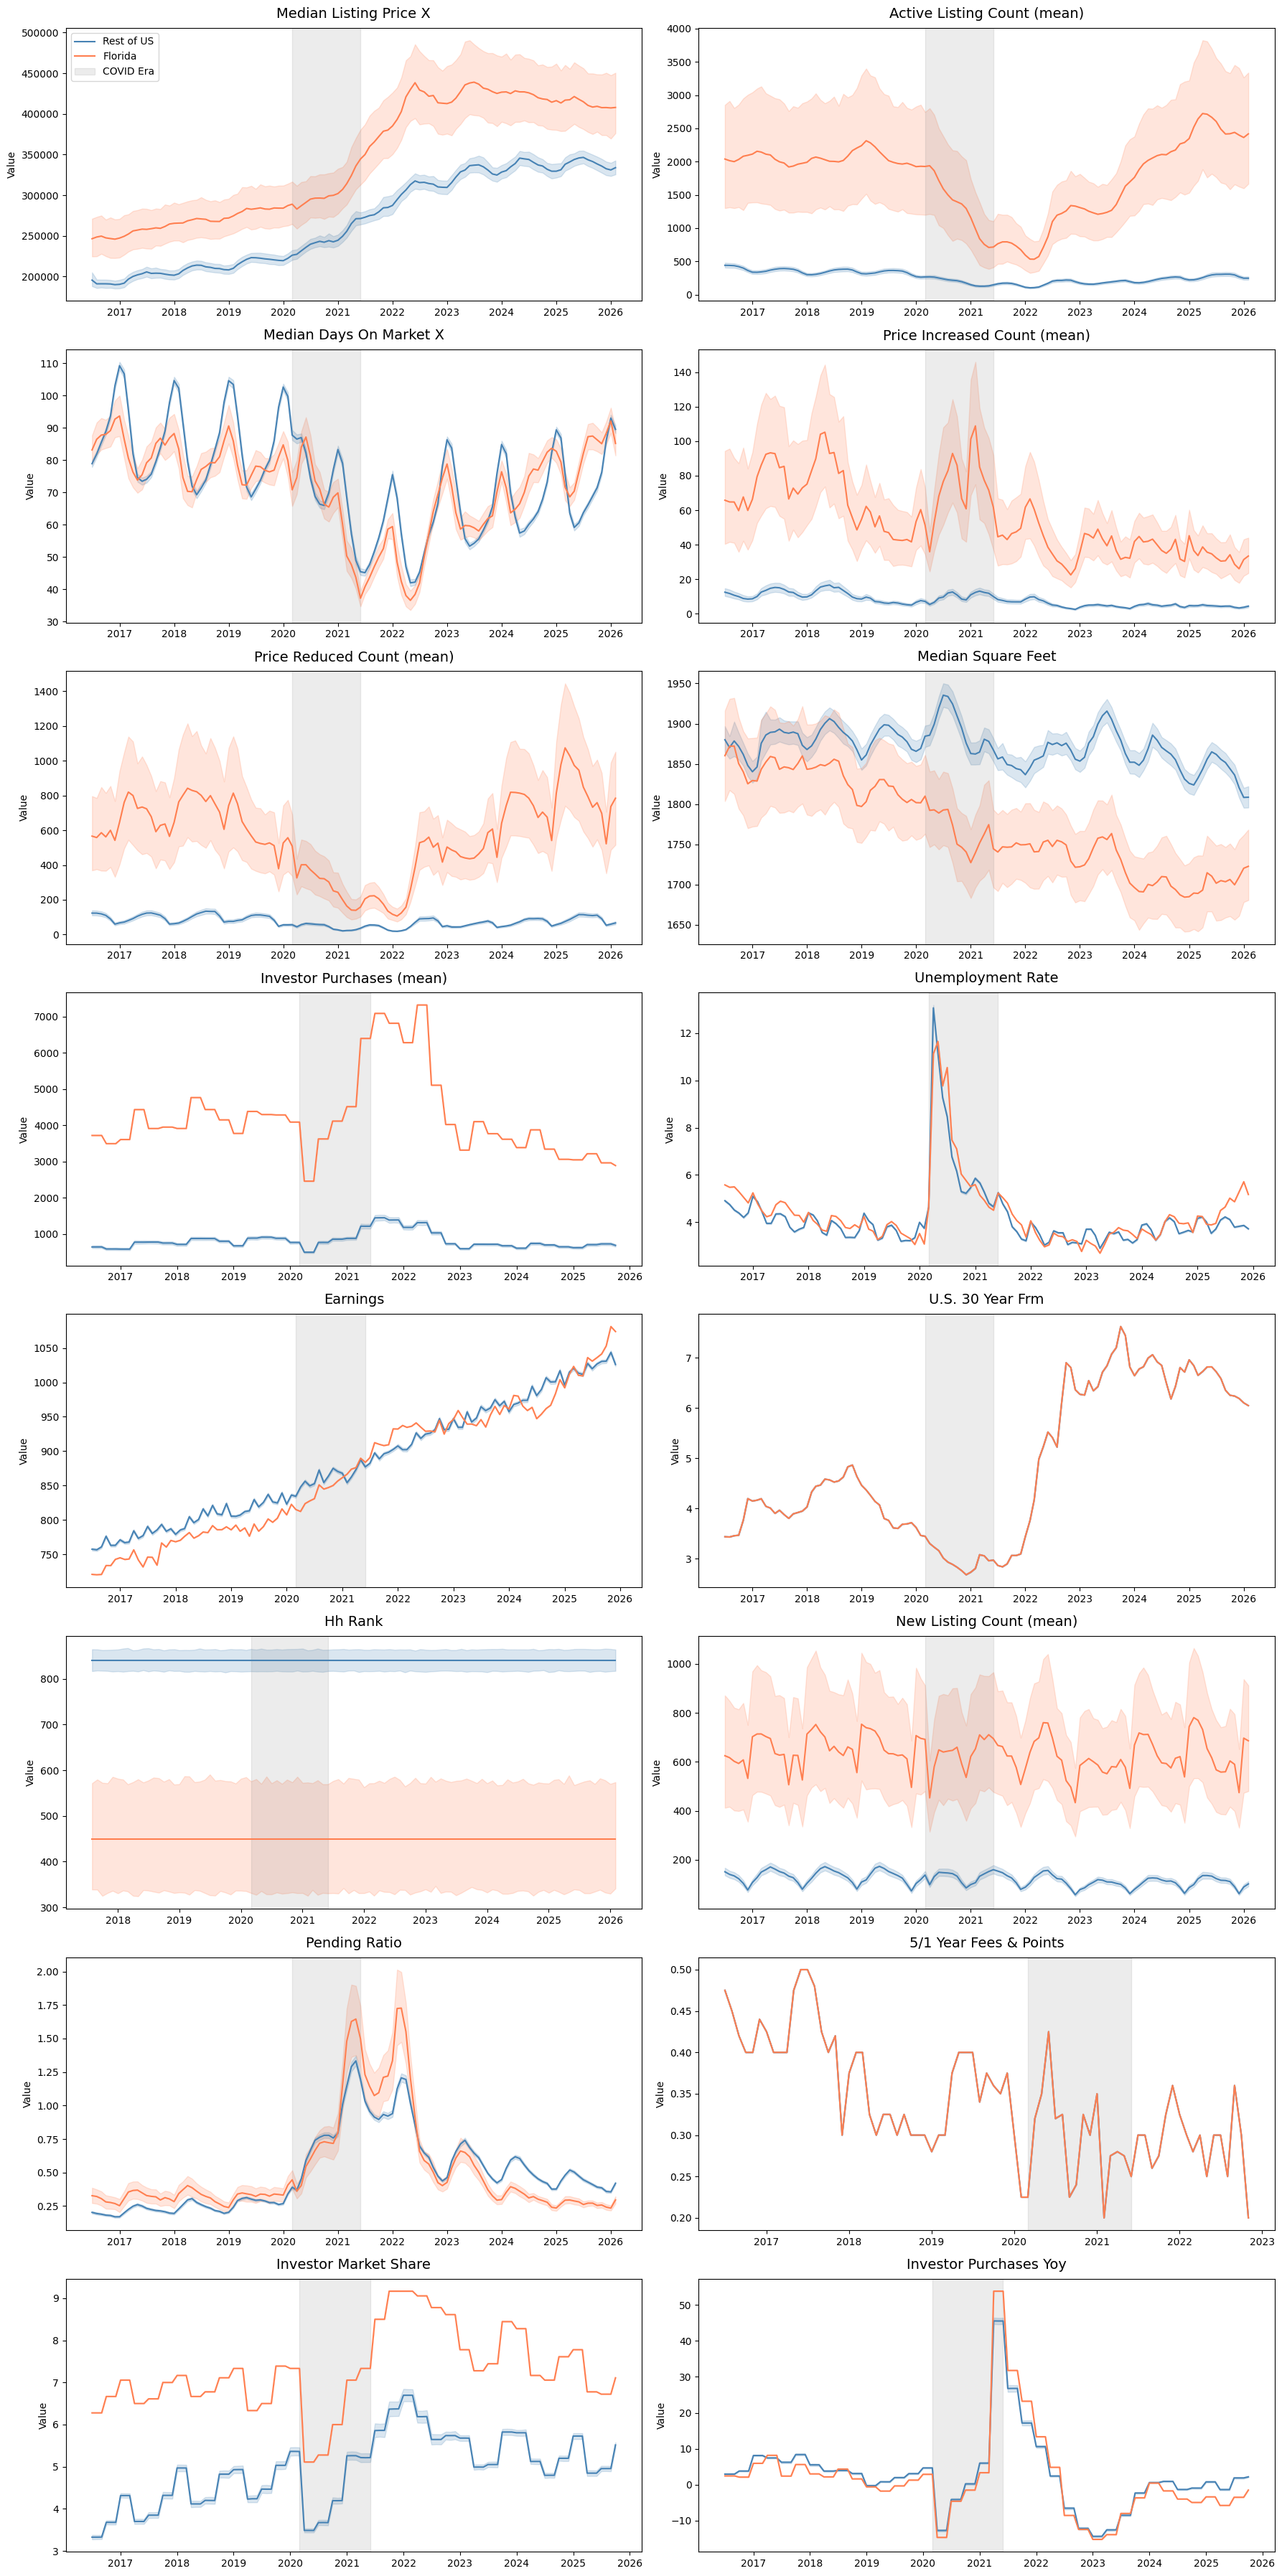

In [5]:
# Create a 'Region' column to split the dataset
df['Region'] = 'Rest of US'

# Change Region value to Florida for state_id = fl
df.loc[df['state'] == 'fl', 'Region'] = 'Florida' 

# Select relevant features to plot

columns_to_plot = [
    'median_listing_price_x', 'active_listing_count', 'median_days_on_market_x', 
    'price_increased_count', 'price_reduced_count', 'median_square_feet',  
    'Investor Purchases', 'Unemployment_Rate', 'Earnings', 'U.S. 30 year FRM',
    'hh_rank', 'new_listing_count', 'pending_ratio', '5/1 year fees & points',
    'Investor Market Share', 'Investor Purchases YoY'
]

# Set up plot
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(18, 36))
axes = axes.flatten()

# Define COVID era shading boundaries (Year-Month-Day)
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2021-05-31')

import matplotlib.patches as mpatches

# The specific columns that need "(mean)" added to their title
mean_title_cols = [
    'active_listing_count', 
    'price_increased_count', 
    'price_reduced_count', 
    'new_listing_count', 
    'Investor Purchases'
]

# plot
for i, col in enumerate(columns_to_plot):
    if col in df.columns:
        # Plot both regions on the same axis (using the default mean estimator)
        sns.lineplot(
            data=df, x='date', y=col, hue='Region', 
            ax=axes[i], palette={'Florida': 'coral', 'Rest of US': 'steelblue'}
        )
        
        # Clean up the titles (e.g., changes 'median_listing_price_x' to 'Median Listing Price X')
        clean_title = col.replace('_', ' ').title()
        
        # APPEND "(mean)" IF IT IS A COUNT VARIABLE
        if col in mean_title_cols:
            clean_title += " (mean)"
            
        axes[i].set_title(clean_title, fontsize=14, pad=10)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Value')
        
        # Add the light shading for the COVID era
        axes[i].axvspan(covid_start, covid_end, color='gray', alpha=0.15)
        
        # Only keep the legend on the very first plot
        if i == 0:
            covid_patch = mpatches.Patch(color='gray', alpha=0.15, label='COVID Era')
            handles, labels = axes[i].get_legend_handles_labels()
            axes[i].legend(handles=handles + [covid_patch], loc='best')
        else:
            axes[i].get_legend().remove()
            
    else:
        axes[i].set_visible(False)
        print(f"Warning: Column '{col}' not found. Check capitalization!")

# Adjust the layout to keep it looking clean
plt.tight_layout()
plt.show()

